In [6]:
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import calculate_default_transform, reproject
from rasterio.mask import mask
from shapely.geometry import box, mapping
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# --------------------------------------------------------------------
# Paths
# --------------------------------------------------------------------
BASE = Path("C:/Users/EmmaGolub/Desktop/MRoS_local/local_data/")
DEM_10M = BASE / "DEM_AOI_TNM_10m.tif"
DEM_1KM = BASE / "DEM_1km.tif"
DEM_1KM_CLIP = BASE / "DEM_1km_clipped.tif"

# --------------------------------------------------------------------
# 1. Load original DEM
# --------------------------------------------------------------------
with rasterio.open(DEM_10M) as src:
    print("Original CRS:", src.crs)
    print("Original resolution:", src.res)

# --------------------------------------------------------------------
# 2. Reproject DEM → UTM Zone 11N (EPSG:26911)
# --------------------------------------------------------------------
dst_crs = "EPSG:26911"

with rasterio.open(DEM_10M) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )

    profile = src.profile.copy()
    profile.update({
        "crs": dst_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    dem_utm = np.empty((height, width), dtype=np.float32)

    reproject(
        source=src.read(1),
        destination=dem_utm,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear
    )

print("Reprojection complete.")

# --------------------------------------------------------------------
# 3. Resample to 1 km resolution (averaging)
# --------------------------------------------------------------------
orig_res_x = abs(profile["transform"].a)
orig_res_y = abs(profile["transform"].e)
target_res = 1000  # meters

scale_x = orig_res_x / target_res
scale_y = orig_res_y / target_res

new_width  = int(width * scale_x)
new_height = int(height * scale_y)

dst_transform = rasterio.Affine(
    target_res, 0, profile["transform"].c,
    0, -target_res, profile["transform"].f
)

dem_1km = np.empty((new_height, new_width), dtype=np.float32)

reproject(
    source=dem_utm,
    destination=dem_1km,
    src_transform=profile["transform"],
    src_crs=dst_crs,
    dst_transform=dst_transform,
    dst_crs=dst_crs,
    resampling=Resampling.average
)

km_profile = {
    "driver": "GTiff",
    "height": new_height,
    "width": new_width,
    "count": 1,
    "dtype": "float32",
    "crs": dst_crs,
    "transform": dst_transform,
    "compress": "lzw"
}

if DEM_1KM.exists():
    DEM_1KM.unlink()

with rasterio.open(DEM_1KM, "w", **km_profile) as dst:
    dst.write(dem_1km, 1)

print("Saved:", DEM_1KM)

# --------------------------------------------------------------------
# 4. Compute SAFE INTERIOR CLIP BOUNDS
# --------------------------------------------------------------------
with rasterio.open(DEM_1KM) as src:
    full_bounds = src.bounds
    res = abs(src.transform.a)  # should be 1000 m

print("Full DEM bounds:", full_bounds)
print("Pixel size:", res)

# shrink by EXACTLY 1 pixel on each side
xmin = full_bounds.left   + res
ymin = full_bounds.bottom + res
xmax = full_bounds.right  - res
ymax = full_bounds.top    - res

print("Interior (NaN-free) clip bounds:")
print(xmin, ymin, xmax, ymax)

interior_poly = box(xmin, ymin, xmax, ymax)

# --------------------------------------------------------------------
# 5. Clip the DEM to interior bounds → zero NaNs
# --------------------------------------------------------------------
with rasterio.open(DEM_1KM) as src:
    out_image, out_transform = mask(
        src,
        [mapping(interior_poly)],
        crop=True,
        filled=True,   # should not introduce NaNs since interior is valid
        nodata=None
    )

    out_profile = src.profile.copy()
    out_profile.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform,
        "dtype": "float32",
        "nodata": None
    })

if DEM_1KM_CLIP.exists():
    DEM_1KM_CLIP.unlink()

with rasterio.open(DEM_1KM_CLIP, "w", **out_profile) as dst:
    dst.write(out_image[0], 1)

print("Saved NaN-free clipped DEM:", DEM_1KM_CLIP)

# --------------------------------------------------------------------
# 6. Diagnostics
# --------------------------------------------------------------------
arr = out_image[0].astype(float)

print("\n--- Final DEM Diagnostics (should have ZERO NaNs) ---")
print("Shape:", arr.shape)
print("NaNs:", np.isnan(arr).sum())
print("Min/Max:", np.nanmin(arr), np.nanmax(arr))


Original CRS: EPSG:4269
Original resolution: (9.259259266022047e-05, 9.259259265990936e-05)
Reprojection complete.
Saved: C:\Users\EmmaGolub\Desktop\MRoS_local\local_data\DEM_1km.tif
Full DEM bounds: BoundingBox(left=137130.9182594687, bottom=3929426.168783374, right=414130.9182594687, top=4435426.168783374)
Pixel size: 1000.0
Interior (NaN-free) clip bounds:
138130.9182594687 3930426.168783374 413130.9182594687 4434426.168783374
Saved NaN-free clipped DEM: C:\Users\EmmaGolub\Desktop\MRoS_local\local_data\DEM_1km_clipped.tif

--- Final DEM Diagnostics (should have ZERO NaNs) ---
Shape: (504, 275)
NaNs: 0
Min/Max: 0.0 4110.95263671875


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_18016\3268701395.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


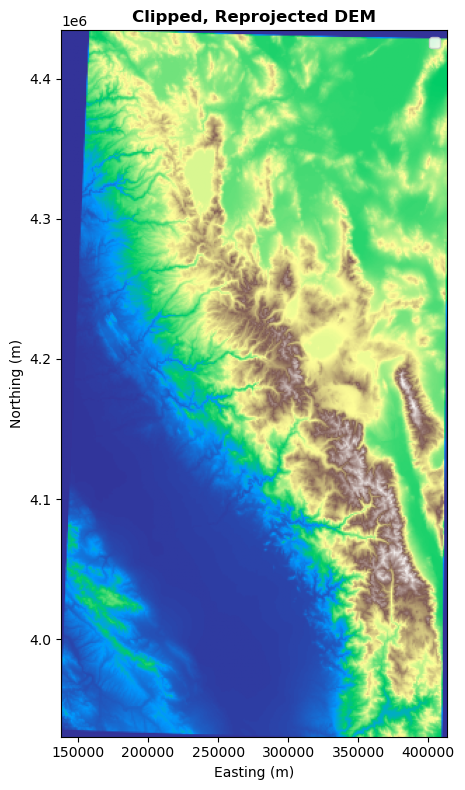

In [7]:
with rasterio.open(DEM_1KM_CLIP) as src:
    fig, ax = plt.subplots(figsize=(10, 8))
    show(src, ax=ax, cmap="terrain", title="Clipped, Reprojected DEM")

plt.legend()
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.tight_layout()
plt.show()

In [8]:
import numpy as np

dem_path = DEM_1KM_CLIP  # path object from above

with rasterio.open(dem_path) as src:
    arr = src.read(1).astype(float)
    transform = src.transform
    crs = src.crs
    bounds = src.bounds
    res = (abs(transform.a), abs(transform.e))

print("=====================================================")
print(" DEM Diagnostics")
print("=====================================================")
print(f"File: {dem_path}")
print(f"CRS: {crs}")
print(f"Resolution: {res[0]:.2f} x {res[1]:.2f} m")
print(f"Shape: {arr.shape}  (rows x cols)")
print(f"Bounds: {bounds}")

# Basic stats
print("\n--- Basic Statistics ---")
print(f"Min: {np.nanmin(arr):.2f}")
print(f"Max: {np.nanmax(arr):.2f}")
print(f"Mean: {np.nanmean(arr):.2f}")
print(f"Std Dev: {np.nanstd(arr):.2f}")

# NaN / Inf checks
print("\n--- Data Integrity ---")
print(f"NaNs:   {np.isnan(arr).sum():,}")
print(f"+Inf:   {np.isposinf(arr).sum():,}")
print(f"-Inf:   {np.isneginf(arr).sum():,}")

# Unique values (optional, careful with big rasters)
uniq_vals = np.unique(arr[~np.isnan(arr)])
print(f"\nUnique values (clipped sample): {uniq_vals[:10]} ... (total {len(uniq_vals)})")


 DEM Diagnostics
File: C:\Users\EmmaGolub\Desktop\MRoS_local\local_data\DEM_1km_clipped.tif
CRS: EPSG:26911
Resolution: 1000.00 x 1000.00 m
Shape: (504, 275)  (rows x cols)
Bounds: BoundingBox(left=138130.9182594687, bottom=3930426.168783374, right=413130.9182594687, top=4434426.168783374)

--- Basic Statistics ---
Min: 0.00
Max: 4110.95
Mean: 1237.64
Std Dev: 946.94

--- Data Integrity ---
NaNs:   0
+Inf:   0
-Inf:   0

Unique values (clipped sample): [0.         0.00054944 0.01061421 0.04352163 0.06847897 0.08345812
 0.09366957 0.10002416 0.1363693  0.2204534 ] ... (total 131439)
